## Install TabPFN

In [1]:
!pip install -q -q --no-warn-conflicts tabpfn-client tabpfn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.3/504.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00


## Ready Env

In [2]:
import os
from pathlib import Path

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
            Path(KAGGLE_RAW_CSV),
            Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
            Path("/kaggle/input/vlst-data/VLST.csv"),
            Path("/kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv")
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )


def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn

    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    hf = secrets.get_secret("HF_TOKEN")
    tabpfn = secrets.get_secret("TABPFN_TOKEN")
    return hf, tabpfn


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"
OOF_DIR = RESULT_DIR / "oof"
for _path in (RESULT_DIR, FIGURE_DIR, TABLE_DIR, OOF_DIR):
    _path.mkdir(parents=True, exist_ok=True)

try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

_hf_token, _tabpfn_token = _load_tabpfn_tokens()
if _tabpfn_token:
    os.environ["TABPFN_TOKEN"] = _tabpfn_token
if _hf_token:
    os.environ["HF_TOKEN"] = _hf_token

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("OOF_DIR:", OOF_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)
print("are TOKENs ready:", bool(_tabpfn_token) and bool(_hf_token))


Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
FIGURE_DIR: /kaggle/working/modeling_results/figures
TABLE_DIR: /kaggle/working/modeling_results/tables
OOF_DIR: /kaggle/working/modeling_results/oof
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda
are TOKENs ready: True


## Fit and Eval

Classics use library defaults plus class weighting. The inner loop tunes only the F1 threshold.
`GridSearchCV` winners from `baseline_without_tssi.ipynb` are **not** imported.

Three-way comparison on the same nested-CV protocol:
- **Classics** — library defaults plus class weighting.
- **TabPFN (local)** — `from tabpfn import TabPFNClassifier` (normal / no thinking). This is the arm to run now.
- **TabPFN** — `tabpfn_client.TabPFNClassifier` with thinking-high. Constructor left unchanged; toggle it off in `RUN_MODELS` so this pass does not re-fit it. Stored high-effort OOF already exists.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve, f1_score, fbeta_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve,
)

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# High-effort TabPFN (unchanged constructor). Local TabPFN is optional below.
from tabpfn_client import TabPFNClassifier

LOCAL_TABPFN_AVAILABLE = False
LocalTabPFNClassifier = None
try:
    from tabpfn import TabPFNClassifier as LocalTabPFNClassifier

    LOCAL_TABPFN_AVAILABLE = True
except Exception as exc:
    print("Local TabPFN not importable; skipping that arm:", exc)


def _load_stent_encoding():
    """Import the shared 9-level stent-brand encoder.

    On Kaggle the repo tree is usually missing, so this falls back to an
    in-notebook copy of ``code/modeling/tools/stent_encoding.py``.
    """
    import re
    import sys
    from pathlib import Path

    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for extra in (
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("/kaggle/usr/lib"),
    ):
        if extra.is_dir():
            search_roots.append(extra)
            search_roots.extend(extra.glob("*"))

    for d in search_roots:
        for tools in (
            d / "code" / "modeling" / "tools",
            d / "modeling" / "tools",
            d,
        ):
            if (Path(tools) / "stent_encoding.py").is_file():
                tools = Path(tools)
                if str(tools) not in sys.path:
                    sys.path.insert(0, str(tools))
                from stent_encoding import (
                    encode_stent_brand_column,
                    coerce_stent_class_flags,
                )
                print("Stent encoder: imported from", tools / "stent_encoding.py")
                return encode_stent_brand_column, coerce_stent_class_flags

    print("Stent encoder: using in-notebook fallback (Kaggle / no repo tree).")

    STENT_BRAND_RAW_COL = "Stent type-SES"
    STENT_CLASS_FLAG_COLS = ("PES", "ZES", "EVS")
    STENT_BRAND_MIN_COUNT = 30
    _BRAND_ALIASES = {
        "xiencex": "xiencev",
        "resolut": "resolute",
        "parnter": "partner",
        "endeavor": "endeavor",
        "cypher": "cypher",
    }

    def canonicalize_stent_brand(value):
        if pd.isna(value) or str(value).strip() == "":
            return "missing"
        s = str(value).strip().replace("：", ":").lower()
        s = re.sub(r"\s+", "", s)
        if ":" in s:
            s = s.split(":")[-1]
        for sep in ("，", ",", "/"):
            if sep in s:
                s = s.split(sep)[0]
        return _BRAND_ALIASES.get(s, s)

    def collapse_rare_brands(series, min_count=STENT_BRAND_MIN_COUNT):
        counts = series.value_counts()
        rare = set(counts[counts < min_count].index)
        if not rare:
            return series
        return series.where(~series.isin(rare), "other")

    def encode_stent_brand_column(df, *, raw_col=STENT_BRAND_RAW_COL, min_count=STENT_BRAND_MIN_COUNT, inplace=False):
        out = df if inplace else df.copy()
        meta = {
            "column": raw_col,
            "n_raw": 0,
            "n_levels": 0,
            "min_count": min_count,
            "applied": False,
            "value_counts": {},
        }
        if raw_col not in out.columns:
            return out, meta
        raw = out[raw_col]
        if pd.api.types.is_numeric_dtype(raw):
            meta["n_raw"] = int(raw.nunique(dropna=True))
            meta["n_levels"] = meta["n_raw"]
            return out, meta
        n_raw = int(raw.nunique(dropna=True))
        encoded = collapse_rare_brands(raw.map(canonicalize_stent_brand), min_count)
        out[raw_col] = encoded.astype("object")
        meta.update({
            "n_raw": n_raw,
            "n_levels": int(encoded.nunique(dropna=True)),
            "applied": True,
            "value_counts": encoded.value_counts().to_dict(),
        })
        return out, meta

    def coerce_stent_class_flags(df):
        out = df
        for col in STENT_CLASS_FLAG_COLS:
            if col not in out.columns:
                continue
            s = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)
            bad = ~s.isin([0, 1])
            if bad.any():
                raise ValueError(f"{col}: expected 0/1 after coercion, got {out.loc[bad, col].unique()[:10]}")
            out[col] = s
        return out

    return encode_stent_brand_column, coerce_stent_class_flags


encode_stent_brand_column, coerce_stent_class_flags = _load_stent_encoding()


# 1. Load and validate data
df = pd.read_csv(RAW_PATH)
df, _stent_meta = encode_stent_brand_column(df, inplace=True)
df = coerce_stent_class_flags(df)
if _stent_meta.get("applied"):
    print(
        f"Stent brand: {_stent_meta['n_raw']} raw strings -> "
        f"{_stent_meta['n_levels']} levels (min_count={_stent_meta['min_count']})"
    )
TARGET = "Stent thrombosis"
X = df.drop(columns=["NO.", "Name", "Time since stent implantation", TARGET], errors="ignore")
y = df[TARGET].astype(int)
if set(y.unique()) != {0, 1}:
    raise ValueError(f"{TARGET!r} must contain exactly the binary labels 0 and 1.")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
if len(numeric_features) + len(categorical_features) != X.shape[1]:
    unsupported = sorted(set(X.columns) - set(numeric_features) - set(categorical_features))
    raise TypeError(f"Unsupported feature dtypes for columns: {unsupported}")

# 2. Preprocessing is cloned and fitted independently inside every CV split.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
]).set_output(transform="pandas")


def lightgbm_safe_frame(data):
    """Use stable feature names accepted by LightGBM's JSON model format."""
    frame = data.copy() if isinstance(data, pd.DataFrame) else pd.DataFrame(data)
    frame.columns = [f"feature_{index}" for index in range(frame.shape[1])]
    return frame


# 3. Model templates. Average precision (PR-AUC) is the common metric.
# LogisticRegression and RandomForestClassifier have no internal eval_metric;
# both are evaluated with average_precision_score on outer OOF predictions.
#
# GridSearch winners from baseline_without_tssi.ipynb are NOT imported here.
# The inner loop only chooses an F1 threshold.
# Set a flag False to skip an arm (e.g. run only local TabPFN later).
RUN_MODELS = {
    "Logistic Regression": True,
    "Random Forest": True,
    "XGBoost": True,
    "LightGBM": True,
    "CatBoost": True,
    "TabPFN": False,           # client thinking-high (already stored); do not change constructor
    "TabPFN (local)": True,    # normal local TabPFN — no thinking
}

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(
            random_state=42,
            eval_metric="aucpr",
            tree_method="hist",
            device=XGB_DEVICE,
            n_jobs=1 if XGB_DEVICE == "cuda" else -1,
        ))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("safe_feature_names", FunctionTransformer(lightgbm_safe_frame, validate=False)),
        ("clf", LGBMClassifier(
            class_weight="balanced",
            metric="average_precision",
            random_state=42,
            verbose=-1,
            device=LGB_DEVICE,
            n_jobs=1 if LGB_DEVICE == "gpu" else -1,
        ))
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", CatBoostClassifier(
            auto_class_weights="Balanced",
            eval_metric="PRAUC",
            random_state=42,
            verbose=0,
            task_type=CATBOOST_TASK_TYPE,
            **({"devices": "0"} if CATBOOST_TASK_TYPE == "GPU" else {}),
        ))
    ]),
    "TabPFN": TabPFNClassifier(
        thinking_mode=True,
        thinking_effort="high",
        thinking_metric="average_precision",
        random_state=42
    )
}

if LOCAL_TABPFN_AVAILABLE:
    _local_device = "cuda" if CUDA_AVAILABLE else "cpu"
    # TabPFN v3: n_estimators default is "auto" (starts at 8). Passing -1
    # yields num_estimators=0 and crashes in generate_classification_ensemble_configs.
    models["TabPFN (local)"] = LocalTabPFNClassifier(
        device=_local_device,
        n_estimators="auto",
        balance_probabilities=True,
        ignore_pretraining_limits=False,
        random_state=42,
    )
    print(f"Local TabPFN arm ready on device={_local_device}.")
elif RUN_MODELS.get("TabPFN (local)"):
    print("TabPFN (local) requested but `tabpfn` is not installed; arm skipped.")

models = {name: spec for name, spec in models.items() if RUN_MODELS.get(name, True)}
if not models:
    raise ValueError("RUN_MODELS left no models to fit.")
print("Nested-CV arms:", ", ".join(models))
print(f"Classic GPU routing: CatBoost={CATBOOST_TASK_TYPE}, XGB={XGB_DEVICE}, LGB={LGB_DEVICE}")


def fresh_model(model_name, model_template, y_fit):
    """Clone a model and derive label-dependent settings from training data only."""
    model = clone(model_template)
    if model_name == "XGBoost":
        n_positive = int((y_fit == 1).sum())
        n_negative = int((y_fit == 0).sum())
        if n_positive == 0:
            raise ValueError("XGBoost training split contains no positive cases.")
        model.set_params(clf__scale_pos_weight=n_negative / n_positive)
    return model


def optimal_f1_threshold(y_true, probabilities):
    """Choose an F1 threshold using only the supplied calibration labels."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        return 0.5
    f1_values = (
            2 * precisions[:-1] * recalls[:-1]
            / (precisions[:-1] + recalls[:-1] + 1e-10)
    )
    return float(thresholds[int(np.argmax(f1_values))])


# 4. Nested CV: tune thresholds on inner OOF predictions and apply each
# threshold once to that outer fold's unseen validation cases.
OUTER_SPLITS = 5
INNER_SPLITS = 4
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
oof_probabilities = {name: np.zeros(len(X), dtype=float) for name in models}
oof_binary_predictions = {name: np.zeros(len(X), dtype=int) for name in models}
fold_thresholds = {name: [] for name in models}
oof_fold_ids = np.zeros(len(X), dtype=int)

print(f"Running nested {OUTER_SPLITS}-fold outer / {INNER_SPLITS}-fold inner CV...")
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {outer_fold}/{OUTER_SPLITS}...")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    oof_fold_ids[val_idx] = outer_fold
    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=10_000 + outer_fold,
    )

    for model_name, model_template in models.items():
        print(f"  {model_name}: estimating threshold from inner OOF predictions")
        inner_oof_probabilities = np.zeros(len(X_train), dtype=float)
        for inner_train_idx, calibration_idx in inner_cv.split(X_train, y_train):
            X_inner_train = X_train.iloc[inner_train_idx]
            y_inner_train = y_train.iloc[inner_train_idx]
            X_calibration = X_train.iloc[calibration_idx]
            inner_model = fresh_model(model_name, model_template, y_inner_train)
            inner_model.fit(X_inner_train, y_inner_train)
            inner_oof_probabilities[calibration_idx] = inner_model.predict_proba(X_calibration)[:, 1]

        fold_threshold = optimal_f1_threshold(y_train, inner_oof_probabilities)
        fold_thresholds[model_name].append(fold_threshold)
        outer_model = fresh_model(model_name, model_template, y_train)
        outer_model.fit(X_train, y_train)
        val_probabilities = outer_model.predict_proba(X_val)[:, 1]
        oof_probabilities[model_name][val_idx] = val_probabilities
        oof_binary_predictions[model_name][val_idx] = (
                val_probabilities >= fold_threshold
        ).astype(int)

print("Nested CV finished.")
print("OOF arrays ready for:", ", ".join(oof_probabilities))
print("Next cells plot ranking curves, confusion matrices, and the comparison table.")


Running nested 5-fold outer / 4-fold inner CV...
Processing outer fold 1/5...
  Logistic Regression: estimating threshold from inner OOF predictions
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inner OOF predictions
  LightGBM: estimating threshold from inner OOF predictions
  CatBoost: estimating threshold from inner OOF predictions
  TabPFN: estimating threshold from inner OOF predictions


Found existing access token, reusing it for authentication.

00:00 Fitting... \

Train set already exists, skipping upload.


24:38 Fitting... Done!
00:00 Predicting... \

...

00:14 Predicting... Done!
00:00 Fitting... \

Train set already exists, skipping upload.


04:38 Fitting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:15 Predicting... Done!
Nested CV finished.
OOF arrays ready for: Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, TabPFN
Next cells plot ranking curves, confusion matrices, and the comparison table.


## Persist OOF

Write nested-CV out-of-fold labels, probabilities, fold IDs, and inner-CV thresholds to disk so later figures can be rebuilt without re-fitting.


In [4]:
OOF_DIR = Path(RESULT_DIR) / "oof"
OOF_DIR.mkdir(parents=True, exist_ok=True)

if "oof_fold_ids" not in globals():
    oof_fold_ids = np.zeros(len(y), dtype=int)
    _fold_splitter = StratifiedKFold(
        n_splits=OUTER_SPLITS, shuffle=True, random_state=42
    )
    for _fold, (_, _val_idx) in enumerate(_fold_splitter.split(X, y), 1):
        oof_fold_ids[_val_idx] = _fold


def _oof_col(name):
    return name.lower().replace(" ", "_")


oof_df = pd.DataFrame({"y": np.asarray(y, dtype=int), "fold": oof_fold_ids})
for _name in oof_probabilities:
    _key = _oof_col(_name)
    oof_df[f"{_key}_prob"] = np.asarray(oof_probabilities[_name], dtype=float)
    oof_df[f"{_key}_pred"] = np.asarray(oof_binary_predictions[_name], dtype=int)

n_folds_saved = len(next(iter(fold_thresholds.values())))
fold_thr_df = pd.DataFrame(fold_thresholds)
fold_thr_df.insert(0, "fold", np.arange(1, n_folds_saved + 1))

oof_csv = OOF_DIR / "oof_predictions.csv"
thr_csv = OOF_DIR / "fold_thresholds.csv"
oof_df.to_csv(oof_csv, index=False)
fold_thr_df.to_csv(thr_csv, index=False)
print("Saved OOF predictions to:", oof_csv)
print("Saved fold thresholds to:", thr_csv)
print(
    "OOF rows:", len(oof_df),
    "| positives:", int(oof_df["y"].sum()),
    "| folds:", sorted(oof_df["fold"].unique().tolist()),
)


Saved OOF predictions to: /kaggle/working/modeling_results/oof/oof_predictions.csv
Saved fold thresholds to: /kaggle/working/modeling_results/oof/fold_thresholds.csv
OOF rows: 5185 | positives: 92 | folds: [1, 2, 3, 4, 5]


## Ranking curves

Precision-recall and ROC curves from nested-CV out-of-fold probabilities (threshold-independent). The dotted line on the PR panel is the positive-class prevalence.


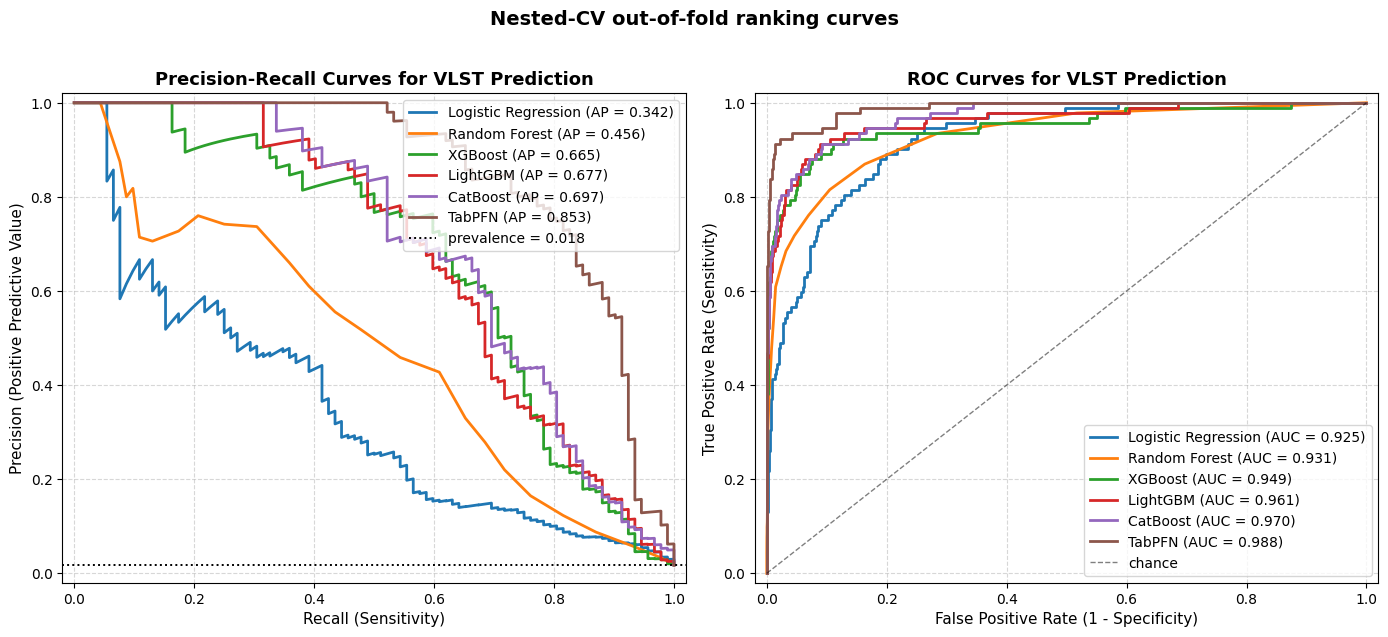

Saved ranking-curve panel to: /kaggle/working/modeling_results/figures/pr_roc_curves.png
Positive-class prevalence: 0.0177


In [5]:
y_true_oof = np.asarray(y)
THRESHOLD_GRID = np.linspace(0.01, 0.99, 199)
prevalence = float(np.mean(y_true_oof))


def best_fbeta_threshold(y_true, scores, beta=1.0, grid=THRESHOLD_GRID):
    best_t, best_s = 0.5, -1.0
    scores = np.asarray(scores)
    for t in grid:
        pred = (scores >= t).astype(int)
        score = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if score > best_s:
            best_s, best_t = score, float(t)
    return best_t


fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for model_name, probabilities in oof_probabilities.items():
    precisions, recalls, _ = precision_recall_curve(y_true_oof, probabilities)
    ap = average_precision_score(y_true_oof, probabilities)
    axes[0].plot(recalls, precisions, lw=2, label=f"{model_name} (AP = {ap:.3f})")

    fpr, tpr, _ = roc_curve(y_true_oof, probabilities)
    auc = roc_auc_score(y_true_oof, probabilities)
    axes[1].plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {auc:.3f})")

axes[0].axhline(prevalence, color="k", ls=":", lw=1.4, label=f"prevalence = {prevalence:.3f}")
axes[0].set_xlabel("Recall (Sensitivity)", fontsize=11)
axes[0].set_ylabel("Precision (Positive Predictive Value)", fontsize=11)
axes[0].set_title("Precision-Recall Curves for VLST Prediction", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="chance")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[1].set_title("ROC Curves for VLST Prediction", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

fig.suptitle("Nested-CV out-of-fold ranking curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
pr_roc_path = FIGURE_DIR / "pr_roc_curves.png"
plt.savefig(pr_roc_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ranking-curve panel to: {pr_roc_path}")
print(f"Positive-class prevalence: {prevalence:.4f}")


## Calibration

Reliability curves from nested-CV out-of-fold probabilities. Quantile bins are used because VLST is rare; Brier score is shown in each title (lower is better).


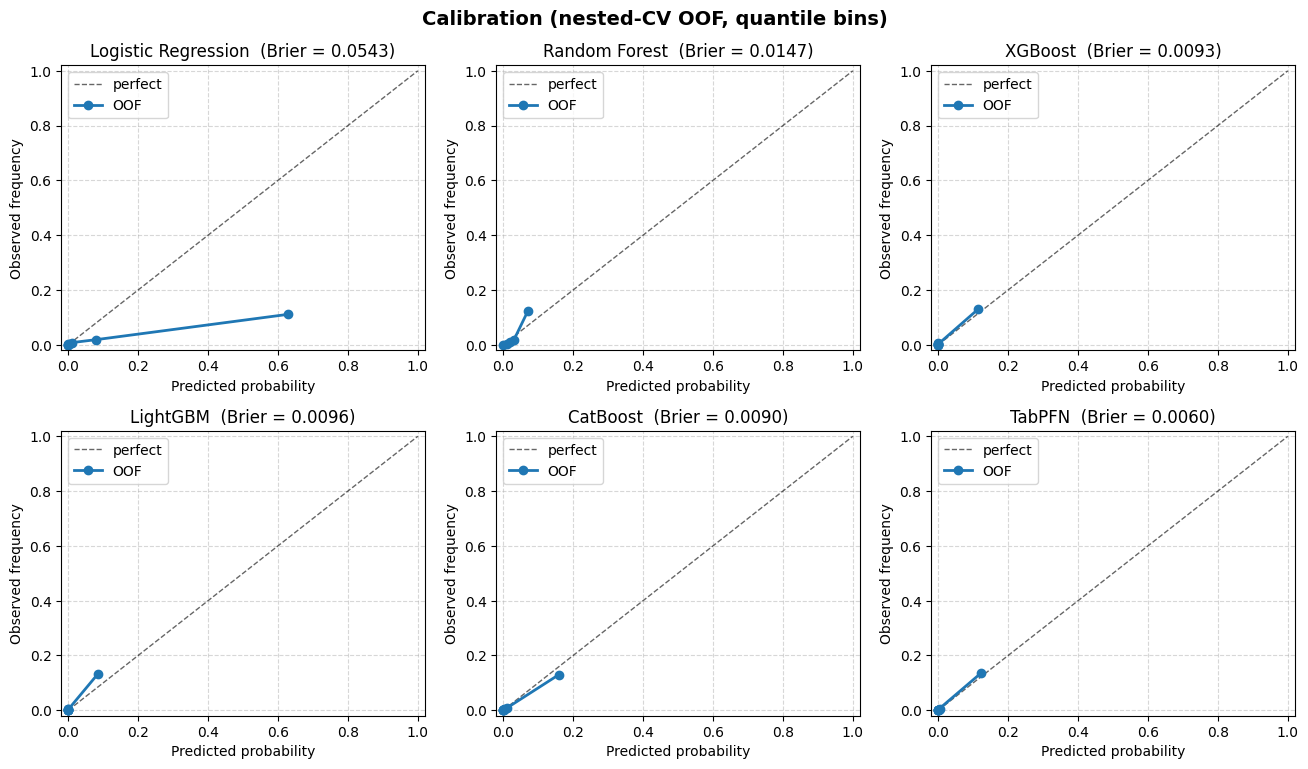

Saved calibration panel to: /kaggle/working/modeling_results/figures/calibration_curves.png
  Logistic Regression: Brier = 0.0543
  Random Forest: Brier = 0.0147
  XGBoost: Brier = 0.0093
  LightGBM: Brier = 0.0096
  CatBoost: Brier = 0.0090
  TabPFN: Brier = 0.0060


In [6]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

n_models = len(oof_probabilities)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.9 * n_rows))
axes = np.atleast_1d(axes).ravel()
brier_scores = {}

for ax, (model_name, probabilities) in zip(axes, oof_probabilities.items()):
    probs = np.asarray(probabilities, dtype=float)
    brier = brier_score_loss(y_true_oof, probs)
    brier_scores[model_name] = float(brier)
    try:
        frac_pos, mean_pred = calibration_curve(
            y_true_oof, probs, n_bins=8, strategy="quantile"
        )
    except ValueError:
        frac_pos, mean_pred = calibration_curve(
            y_true_oof, probs, n_bins=5, strategy="uniform"
        )
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="perfect")
    ax.plot(mean_pred, frac_pos, "o-", lw=2, label="OOF")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"{model_name}  (Brier = {brier:.4f})")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Calibration (nested-CV OOF, quantile bins)", fontsize=14, fontweight="bold")
plt.tight_layout()
cal_path = FIGURE_DIR / "calibration_curves.png"
plt.savefig(cal_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved calibration panel to: {cal_path}")
for _name, _brier in brier_scores.items():
    print(f"  {_name}: Brier = {_brier:.4f}")


## Confusion matrices

Heatmaps at each model's **F1-optimal** out-of-fold threshold (same operating point as the F1 block of the comparison table).


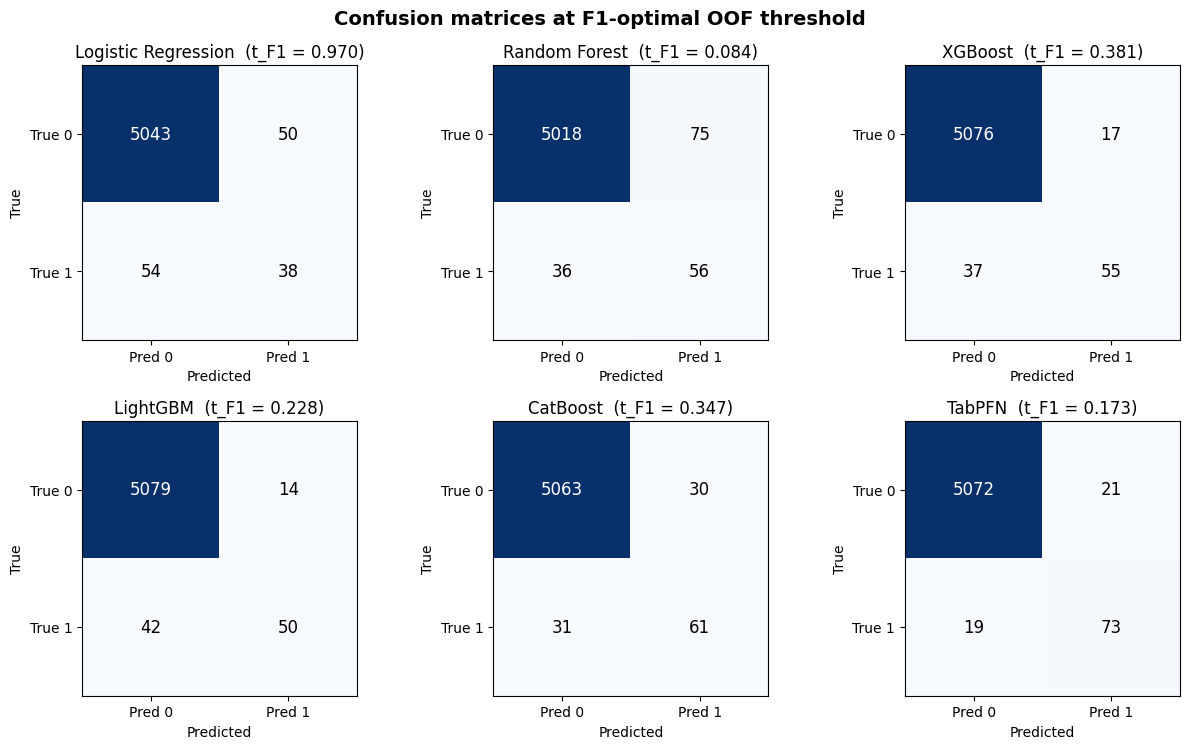

Saved confusion-matrix panel to: /kaggle/working/modeling_results/figures/confusion_matrices.png


In [7]:
cms_at_f1 = {}
f1_thresholds = {}
n_models = len(oof_probabilities)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, probabilities) in zip(axes, oof_probabilities.items()):
    t_f1 = best_fbeta_threshold(y_true_oof, probabilities, beta=1.0)
    pred = (np.asarray(probabilities) >= t_f1).astype(int)
    cm = confusion_matrix(y_true_oof, pred, labels=[0, 1])
    cms_at_f1[model_name] = cm
    f1_thresholds[model_name] = t_f1
    ax.imshow(cm, cmap="Blues")
    for (i, j), val in np.ndenumerate(cm):
        ax.text(
            j, i, f"{val:d}", ha="center", va="center", fontsize=12,
            color="white" if val > cm.max() / 2 else "black",
        )
    ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], ["True 0", "True 1"])
    ax.set_title(f"{model_name}  (t_F1 = {t_f1:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Confusion matrices at F1-optimal OOF threshold", fontsize=14, fontweight="bold")
plt.tight_layout()
cm_path = FIGURE_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved confusion-matrix panel to: {cm_path}")


## Model comparison table

Threshold-independent ranking (pooled PR-AUC / ROC-AUC / Brier, plus fold-wise mean +/- SD) and operating-point metrics at the F1-optimal out-of-fold threshold. Nested-CV fold-specific F1 operating points are saved alongside.


In [8]:
from IPython.display import display
from sklearn.metrics import brier_score_loss

if "oof_fold_ids" not in globals():
    oof_fold_ids = np.zeros(len(y), dtype=int)
    _fold_splitter = StratifiedKFold(
        n_splits=OUTER_SPLITS, shuffle=True, random_state=42
    )
    for _fold, (_, _val_idx) in enumerate(_fold_splitter.split(X, y), 1):
        oof_fold_ids[_val_idx] = _fold


def metrics_at_threshold(y_true, scores, threshold):
    pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2.0, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


rows = []
nested_rows = []
fold_rows = []
for model_name, probabilities in oof_probabilities.items():
    probs = np.asarray(probabilities, dtype=float)
    t_f1 = best_fbeta_threshold(y_true_oof, probs, beta=1.0)
    m_f1 = metrics_at_threshold(y_true_oof, probs, t_f1)
    fold_t = np.asarray(fold_thresholds[model_name], dtype=float)
    nested = metrics_at_threshold(
        y_true_oof, oof_binary_predictions[model_name].astype(float), 0.5
    )
    fold_pr = []
    fold_roc = []
    for fold in sorted(np.unique(oof_fold_ids)):
        mask = oof_fold_ids == fold
        pr_fold = average_precision_score(y_true_oof[mask], probs[mask])
        roc_fold = roc_auc_score(y_true_oof[mask], probs[mask])
        fold_pr.append(pr_fold)
        fold_roc.append(roc_fold)
        fold_rows.append({
            "model": model_name,
            "fold": int(fold),
            "n": int(mask.sum()),
            "n_pos": int(y_true_oof[mask].sum()),
            "pr_auc": pr_fold,
            "roc_auc": roc_fold,
        })
    rows.append({
        "model": model_name,
        "pr_auc": average_precision_score(y_true_oof, probs),
        "roc_auc": roc_auc_score(y_true_oof, probs),
        "brier": brier_score_loss(y_true_oof, probs),
        "pr_auc_mean": float(np.mean(fold_pr)),
        "pr_auc_sd": float(np.std(fold_pr, ddof=1)) if len(fold_pr) > 1 else 0.0,
        "roc_auc_mean": float(np.mean(fold_roc)),
        "roc_auc_sd": float(np.std(fold_roc, ddof=1)) if len(fold_roc) > 1 else 0.0,
        "t_f1": m_f1["threshold"],
        "acc_f1": m_f1["accuracy"],
        "prec_f1": m_f1["precision"],
        "rec_f1": m_f1["recall"],
        "spec_f1": m_f1["specificity"],
        "f1_at_t_f1": m_f1["f1"],
        "f2_at_t_f1": m_f1["f2"],
        "tn_f1": m_f1["tn"],
        "fp_f1": m_f1["fp"],
        "fn_f1": m_f1["fn"],
        "tp_f1": m_f1["tp"],
    })
    nested_rows.append({
        "model": model_name,
        "threshold_mean": float(fold_t.mean()),
        "threshold_sd": float(fold_t.std(ddof=1)) if fold_t.size > 1 else 0.0,
        "accuracy": nested["accuracy"],
        "precision": nested["precision"],
        "recall": nested["recall"],
        "specificity": nested["specificity"],
        "f1": nested["f1"],
        "f2": nested["f2"],
        "tn": nested["tn"],
        "fp": nested["fp"],
        "fn": nested["fn"],
        "tp": nested["tp"],
        "pr_auc": average_precision_score(y_true_oof, probs),
        "roc_auc": roc_auc_score(y_true_oof, probs),
    })

comparison_df = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
nested_df = pd.DataFrame(nested_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
fold_metrics_df = pd.DataFrame(fold_rows)


def _fmt_block(df, cols, float_cols, thresh_cols=()):
    out = df[cols].copy()
    for col in thresh_cols:
        out[col] = out[col].map(lambda v: f"{v:.3f}")
    for col in float_cols:
        out[col] = out[col].map(lambda v: f"{v:.4f}")
    return out


ranking_view = comparison_df.copy()
ranking_view["pr_auc_fold"] = ranking_view.apply(
    lambda r: f"{r['pr_auc_mean']:.4f}+/-{r['pr_auc_sd']:.4f}", axis=1
)
ranking_view["roc_auc_fold"] = ranking_view.apply(
    lambda r: f"{r['roc_auc_mean']:.4f}+/-{r['roc_auc_sd']:.4f}", axis=1
)

print("=== SUPER TABLE: ranking (pooled OOF + fold mean+/-SD) ===")
display(_fmt_block(
    ranking_view,
    ["model", "pr_auc", "pr_auc_fold", "roc_auc", "roc_auc_fold", "brier"],
    ["pr_auc", "roc_auc", "brier"],
))

print()
print("=== SUPER TABLE: ranking + F1-optimal OOF threshold ===")
display(_fmt_block(
    comparison_df,
    ["model", "pr_auc", "roc_auc", "t_f1", "acc_f1", "prec_f1", "rec_f1",
     "spec_f1", "f1_at_t_f1", "f2_at_t_f1", "tn_f1", "fp_f1", "fn_f1", "tp_f1"],
    ["pr_auc", "roc_auc", "acc_f1", "prec_f1", "rec_f1", "spec_f1", "f1_at_t_f1", "f2_at_t_f1"],
    thresh_cols=["t_f1"],
))

print()
print("=== NESTED-CV OPERATING POINT (fold-specific inner F1 thresholds) ===")
nested_display = nested_df.copy()
nested_display["threshold"] = nested_display.apply(
    lambda r: f"{r['threshold_mean']:.3f}+/-{r['threshold_sd']:.3f}", axis=1
)
display(_fmt_block(
    nested_display,
    ["model", "threshold", "accuracy", "precision", "recall", "specificity",
     "f1", "f2", "pr_auc", "roc_auc", "tn", "fp", "fn", "tp"],
    ["accuracy", "precision", "recall", "specificity", "f1", "f2", "pr_auc", "roc_auc"],
))

print()
print("=== FOLD-WISE RANKING METRICS ===")
fold_show = fold_metrics_df.copy()
for col in ["pr_auc", "roc_auc"]:
    fold_show[col] = fold_show[col].map(lambda v: f"{v:.4f}")
display(fold_show)

cm_table = (
    comparison_df[["model", "t_f1", "tn_f1", "fp_f1", "fn_f1", "tp_f1"]]
    .rename(columns={"t_f1": "threshold", "tn_f1": "tn", "fp_f1": "fp", "fn_f1": "fn", "tp_f1": "tp"})
    .assign(strategy="f1")
    [["model", "strategy", "threshold", "tn", "fp", "fn", "tp"]]
)

comparison_path = TABLE_DIR / "model_comparison.csv"
nested_path = TABLE_DIR / "nested_cv_operating_point.csv"
cm_counts_path = TABLE_DIR / "confusion_counts.csv"
fold_path = TABLE_DIR / "fold_metrics.csv"
comparison_df.to_csv(comparison_path, index=False)
nested_df.to_csv(nested_path, index=False)
cm_table.to_csv(cm_counts_path, index=False)
fold_metrics_df.to_csv(fold_path, index=False)
print()
print("Saved tables to:")
print(" ", comparison_path)
print(" ", nested_path)
print(" ", cm_counts_path)
print(" ", fold_path)


=== SUPER TABLE: ranking (pooled OOF + fold mean+/-SD) ===


,model,pr_auc,pr_auc_fold,roc_auc,roc_auc_fold,brier
0,TabPFN,0.8534,0.8503+/-0.0746,0.9883,0.9884+/-0.0061,0.0060
1,CatBoost,0.6967,0.7007+/-0.0684,0.9704,0.9712+/-0.0117,0.0090
2,LightGBM,0.6770,0.6841+/-0.0937,0.9613,0.9633+/-0.0198,0.0096
3,XGBoost,0.6647,0.6792+/-0.0883,0.9493,0.9492+/-0.0343,0.0093
4,Random Forest,0.4563,0.4740+/-0.0319,0.9313,0.9304+/-0.0186,0.0147
5,Logistic Regression,0.3418,0.3568+/-0.1153,0.9246,0.9256+/-0.0225,0.0543



=== SUPER TABLE: ranking + F1-optimal OOF threshold ===


,model,pr_auc,roc_auc,t_f1,acc_f1,prec_f1,rec_f1,spec_f1,f1_at_t_f1,f2_at_t_f1,tn_f1,fp_f1,fn_f1,tp_f1
0,TabPFN,0.8534,0.9883,0.173,0.9923,0.7766,0.7935,0.9959,0.7849,0.7900,5072,21,19,73
1,CatBoost,0.6967,0.9704,0.347,0.9882,0.6703,0.6630,0.9941,0.6667,0.6645,5063,30,31,61
2,LightGBM,0.6770,0.9613,0.228,0.9892,0.7812,0.5435,0.9973,0.6410,0.5787,5079,14,42,50
3,XGBoost,0.6647,0.9493,0.381,0.9896,0.7639,0.5978,0.9967,0.6707,0.6250,5076,17,37,55
4,Random Forest,0.4563,0.9313,0.084,0.9786,0.4275,0.6087,0.9853,0.5022,0.5611,5018,75,36,56
5,Logistic Regression,0.3418,0.9246,0.970,0.9799,0.4318,0.4130,0.9902,0.4222,0.4167,5043,50,54,38



=== NESTED-CV OPERATING POINT (fold-specific inner F1 thresholds) ===


,model,threshold,accuracy,precision,recall,specificity,f1,f2,pr_auc,roc_auc,tn,fp,fn,tp
0,TabPFN,0.297+/-0.053,0.9925,0.8354,0.7174,0.9974,0.7719,0.7383,0.8534,0.9883,5080,13,26,66
1,CatBoost,0.317+/-0.068,0.9867,0.6211,0.6413,0.9929,0.6310,0.6371,0.6967,0.9704,5057,36,33,59
2,LightGBM,0.099+/-0.048,0.9863,0.6154,0.6087,0.9931,0.6120,0.6100,0.6770,0.9613,5058,35,36,56
3,XGBoost,0.237+/-0.072,0.9882,0.6782,0.6413,0.9945,0.6592,0.6484,0.6647,0.9493,5065,28,33,59
4,Random Forest,0.114+/-0.009,0.9834,0.5357,0.4891,0.9923,0.5114,0.4978,0.4563,0.9313,5054,39,47,45
5,Logistic Regression,0.953+/-0.035,0.9757,0.3365,0.3804,0.9865,0.3571,0.3708,0.3418,0.9246,5024,69,57,35



=== FOLD-WISE RANKING METRICS ===


,model,fold,n,n_pos,pr_auc,roc_auc
0,Logistic Regression,1,1037,18,0.2314,0.8911
1,Logistic Regression,2,1037,18,0.2850,0.9440
2,Logistic Regression,3,1037,18,0.3093,0.9147
3,Logistic Regression,4,1037,19,0.4727,0.9420
4,Logistic Regression,5,1037,19,0.4856,0.9361
5,Random Forest,1,1037,18,0.4524,0.8978
6,Random Forest,2,1037,18,0.5101,0.9435
7,Random Forest,3,1037,18,0.4543,0.9362
8,Random Forest,4,1037,19,0.4458,0.9336
9,Random Forest,5,1037,19,0.5075,0.9408



Saved tables to:
  /kaggle/working/modeling_results/tables/model_comparison.csv
  /kaggle/working/modeling_results/tables/nested_cv_operating_point.csv
  /kaggle/working/modeling_results/tables/confusion_counts.csv
  /kaggle/working/modeling_results/tables/fold_metrics.csv


## Threshold sweeps (best model)

Threshold and FP/FN sweeps for the **best model by PR-AUC**, using nested-CV out-of-fold scores.

- **f1** marks the F1-maximising threshold
- FP vs FN traces the same sweep and highlights the chosen operating point


Best model by PR-AUC: TabPFN (AP = 0.8534)


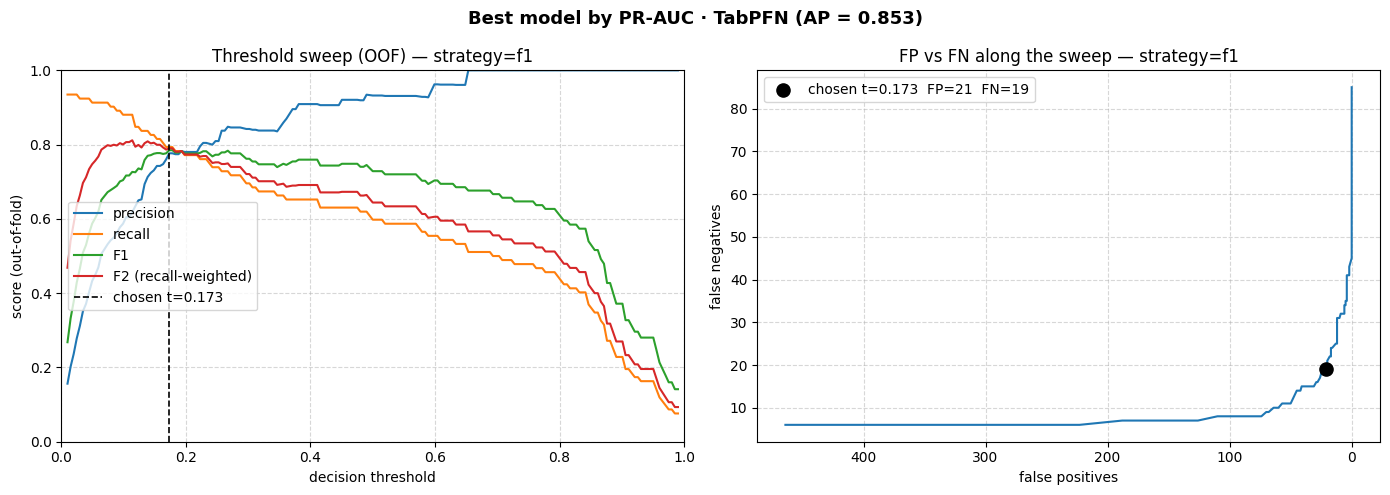

Saved figures panel to: /kaggle/working/modeling_results/figures/best_model_threshold_fpfn_panel.png
Saved sweep tables to:
  /kaggle/working/modeling_results/tables/best_model_threshold_sweep.csv
  /kaggle/working/modeling_results/tables/best_model_operating_points.csv
  f1 threshold = 0.173


In [9]:
best_name, best_ap = max(
    (
        (name, average_precision_score(y_true_oof, probabilities))
        for name, probabilities in oof_probabilities.items()
    ),
    key=lambda item: item[1],
)
best_scores = np.asarray(oof_probabilities[best_name], dtype=float)
print(f"Best model by PR-AUC: {best_name} (AP = {best_ap:.4f})")

grid = THRESHOLD_GRID
precisions = np.empty(grid.size)
recalls = np.empty(grid.size)
f1_values = np.empty(grid.size)
f2_values = np.empty(grid.size)
false_positives = np.empty(grid.size, dtype=int)
false_negatives = np.empty(grid.size, dtype=int)
for i, threshold in enumerate(grid):
    pred = (best_scores >= threshold).astype(int)
    precisions[i] = precision_score(y_true_oof, pred, zero_division=0)
    recalls[i] = recall_score(y_true_oof, pred, zero_division=0)
    f1_values[i] = f1_score(y_true_oof, pred, zero_division=0)
    f2_values[i] = fbeta_score(y_true_oof, pred, beta=2.0, zero_division=0)
    _, fp, fn, _ = confusion_matrix(y_true_oof, pred, labels=[0, 1]).ravel()
    false_positives[i] = int(fp)
    false_negatives[i] = int(fn)

chosen = {
    "f1": float(grid[int(np.argmax(f1_values))]),
}


def _plot_threshold_sweep(ax, strategy, chosen_t):
    ax.plot(grid, precisions, label="precision")
    ax.plot(grid, recalls, label="recall")
    ax.plot(grid, f1_values, label="F1")
    ax.plot(grid, f2_values, label="F2 (recall-weighted)")
    ax.axvline(chosen_t, color="k", ls="--", lw=1.2, label=f"chosen t={chosen_t:.3f}")
    ax.set_xlabel("decision threshold")
    ax.set_ylabel("score (out-of-fold)")
    ax.set_title(f"Threshold sweep (OOF) — strategy={strategy}")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc="center left")
    ax.grid(True, linestyle="--", alpha=0.5)


def _plot_fp_fn_sweep(ax, strategy, chosen_t):
    ax.plot(false_positives, false_negatives, "-", lw=1.5)
    idx = int(np.argmin(np.abs(grid - chosen_t)))
    ax.scatter(
        [false_positives[idx]],
        [false_negatives[idx]],
        s=90,
        color="k",
        zorder=5,
        label=f"chosen t={chosen_t:.3f}  FP={false_positives[idx]}  FN={false_negatives[idx]}",
    )
    ax.set_xlabel("false positives")
    ax.set_ylabel("false negatives")
    ax.set_title(f"FP vs FN along the sweep — strategy={strategy}")
    ax.invert_xaxis()
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_plot_threshold_sweep(axes[0], "f1", chosen["f1"])
_plot_fp_fn_sweep(axes[1], "f1", chosen["f1"])
fig.suptitle(
    f"Best model by PR-AUC · {best_name} (AP = {best_ap:.3f})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
panel_path = FIGURE_DIR / "best_model_threshold_fpfn_panel.png"
plt.savefig(panel_path, dpi=300, bbox_inches="tight")
plt.show()

sweep_table = pd.DataFrame({
    "threshold": grid,
    "precision": precisions,
    "recall": recalls,
    "f1": f1_values,
    "f2": f2_values,
    "fp": false_positives,
    "fn": false_negatives,
})
sweep_csv = TABLE_DIR / "best_model_threshold_sweep.csv"
chosen_csv = TABLE_DIR / "best_model_operating_points.csv"
sweep_table.to_csv(sweep_csv, index=False)
pd.DataFrame(
    [
        {"model": best_name, "strategy": "f1", "threshold": chosen["f1"]},
    ]
).to_csv(chosen_csv, index=False)

print(f"Saved figures panel to: {panel_path}")
print("Saved sweep tables to:")
print(" ", sweep_csv)
print(" ", chosen_csv)
print(f"  f1 threshold = {chosen['f1']:.3f}")
